# Fitting copulas — 6 joint models for three assets



This notebook picks up from notebook 4, which fit three candidate marginal families (Normal, Student-t, Johnson-$S_U$) to each of $m$, $hml$, $smb$ on fold 1 and produced a PIT panel for each family.



**Why 6 joint models, and why this particular layout.** A full cross product would give $3^3 = 27$ marginal combinations times 2 copulas $= 54$ joint models — too many to teach, and each row would mix marginal stories across assets. We tie the marginal family across the three assets so each row carries a single intuition (a "thin-tailed worldview", a "fat-tailed worldview", a "flexible-tailed worldview") and let the copula vary between Gaussian (thin-tailed dependence) and Student-t (fat-tailed dependence, with joint extremes more likely). That gives:



| Marginals | Copula | Joint model |

| --- | --- | --- |

| Normal, Normal, Normal | Gaussian | NNN–G |

| Normal, Normal, Normal | Student-t | NNN–t |

| Student-t, Student-t, Student-t | Gaussian | ttt–G |

| Student-t, Student-t, Student-t | Student-t | ttt–t |

| Johnson-$S_U$, Johnson-$S_U$, Johnson-$S_U$ | Gaussian | JJJ–G |

| Johnson-$S_U$, Johnson-$S_U$, Johnson-$S_U$ | Student-t | JJJ–t |



We do **not** pick a winner here. Selection by realized fold-2 utility happens in notebook 6, mirroring the single-asset workflow in notebook 2.

In [1]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import warnings, pickle, os



from copulae import GaussianCopula, StudentCopula



warnings.filterwarnings("ignore")

np.random.seed(607)



with open("three_asset_state.pkl", "rb") as fh:

    state = pickle.load(fh)



factors          = state["factors"]

families         = state["families"]      # marginal families

marginal_params  = state["marginal_params"]

pit_fold1        = state["pit_fold1"]



print("marginal families:", families)

print("factors:", factors)

marginal families: ['Normal', 'Student t', 'Johnson Su']
factors: ['m', 'hml', 'smb']


## Fit Gaussian and Student-t copulas under each marginal family



For each marginal family $F$, we take its fold-1 PIT panel `pit_fold1[F]` (shape $T \times 3$) and fit two copulas to it: a Gaussian copula and a Student-t copula. The fitted copula objects (which carry their correlation matrix and, for the t-copula, the degrees-of-freedom) will be sampled in notebook 6.

In [2]:
copula_families = ['Gaussian', 'Student-t']



def fit_copula(family_name, pit_panel):

    if family_name == 'Gaussian':

        c = GaussianCopula(dim=3)

    elif family_name == 'Student-t':

        c = StudentCopula(dim=3)

    else:

        raise ValueError(family_name)

    c.fit(pit_panel.values)

    return c



# fitted_copulas[marginal_family][copula_family] = copula object

fitted_copulas = {F: {} for F in families}



for F in families:

    for C in copula_families:

        fitted_copulas[F][C] = fit_copula(C, pit_fold1[F])



# Quick diagnostic: print each fitted copula's parameters

for F in families:

    print(f"=== marginals = {F} ===")

    for C in copula_families:

        cop = fitted_copulas[F][C]

        print(f"  {C} copula: {cop.params}")

    print()

=== marginals = Normal ===
  Gaussian copula: [0.23527138 0.33111965 0.15548907]
  Student-t copula: StudentParams(df=2.48205817774466, rho=array([0.16619175, 0.30731729, 0.11851807]))

=== marginals = Student t ===
  Gaussian copula: [0.2352994  0.3311135  0.15475653]
  Student-t copula: StudentParams(df=2.4875083023536226, rho=array([0.16613404, 0.30815547, 0.11858398]))

=== marginals = Johnson Su ===
  Gaussian copula: [0.2352994  0.3311135  0.15475653]
  Student-t copula: StudentParams(df=2.4875083023536226, rho=array([0.16613404, 0.30815547, 0.11858398]))



## Visual check: simulated PIT scatter under the 6 joint models



For each (marginal family, copula family), we draw $T_1 = |\text{fold 1}|$ uniform 3-vectors from the fitted copula and plot the pairwise scatters. Thin-tailed (Gaussian) copulas show ellipsoidal dependence; fat-tailed (Student-t) copulas show heavier joint extremes — corner-clustering — even though both marginals are uniform on $[0,1]$.

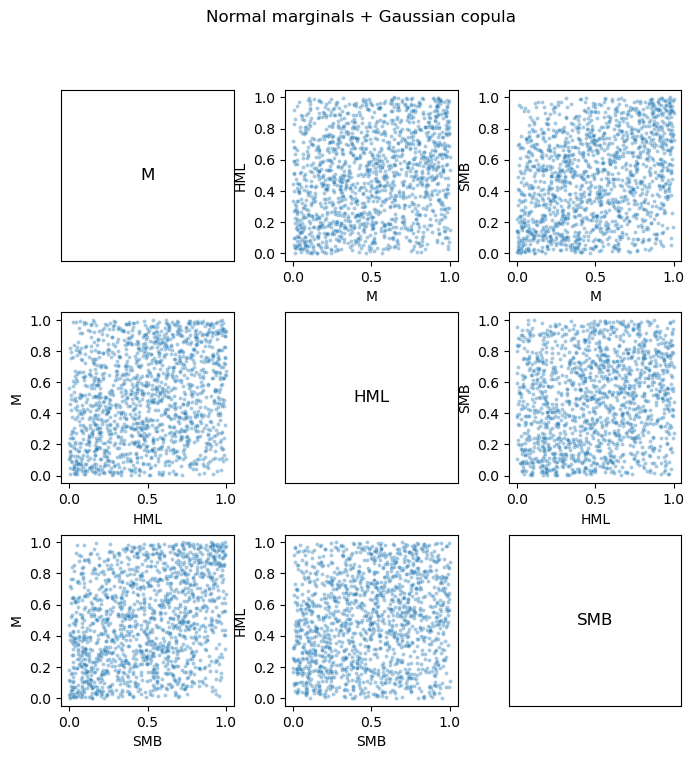

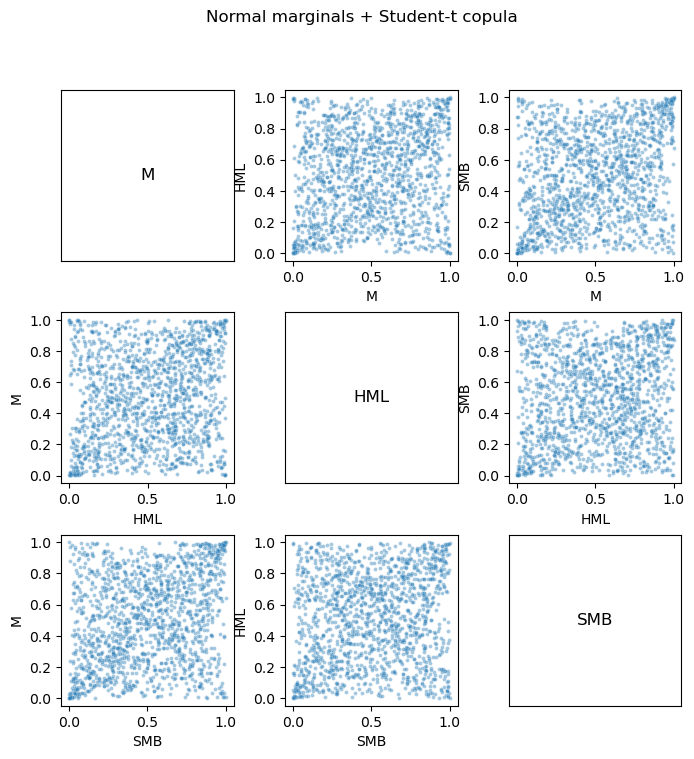

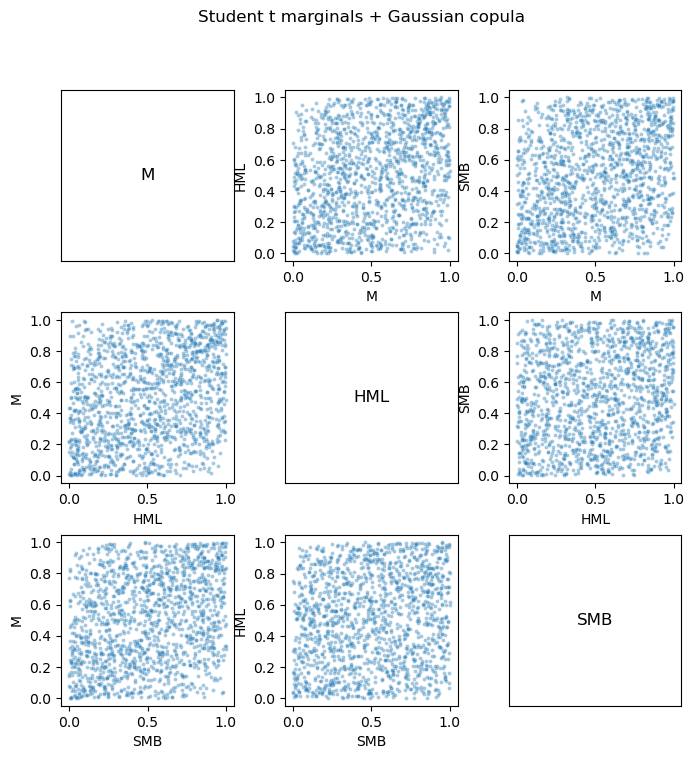

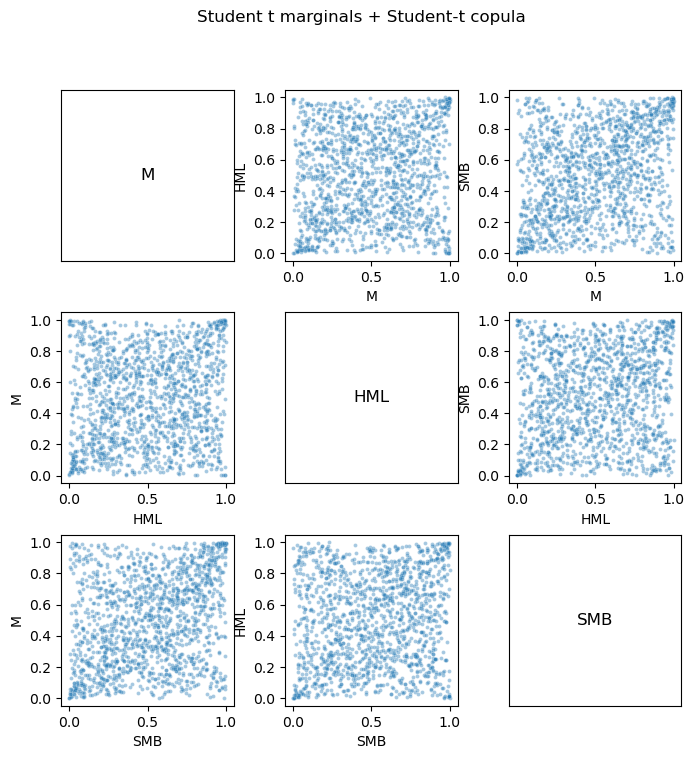

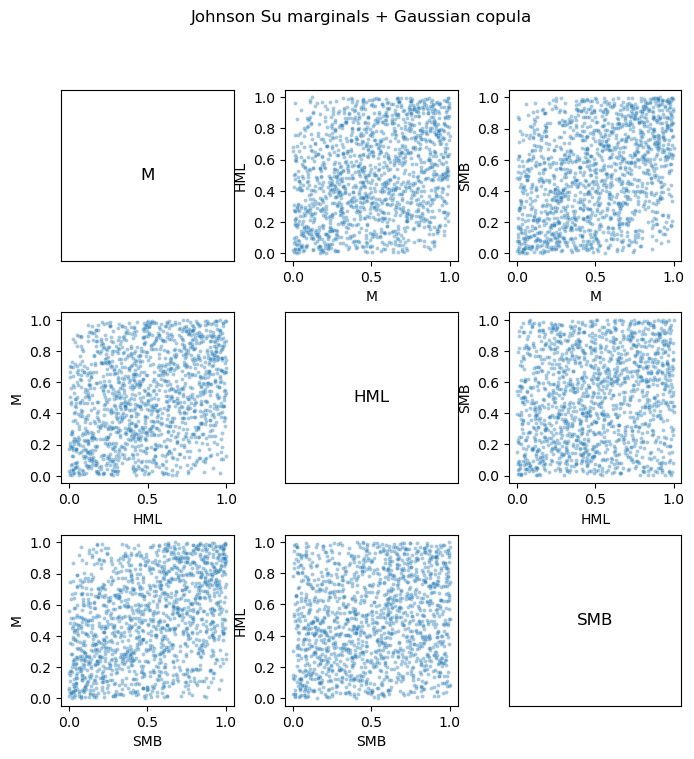

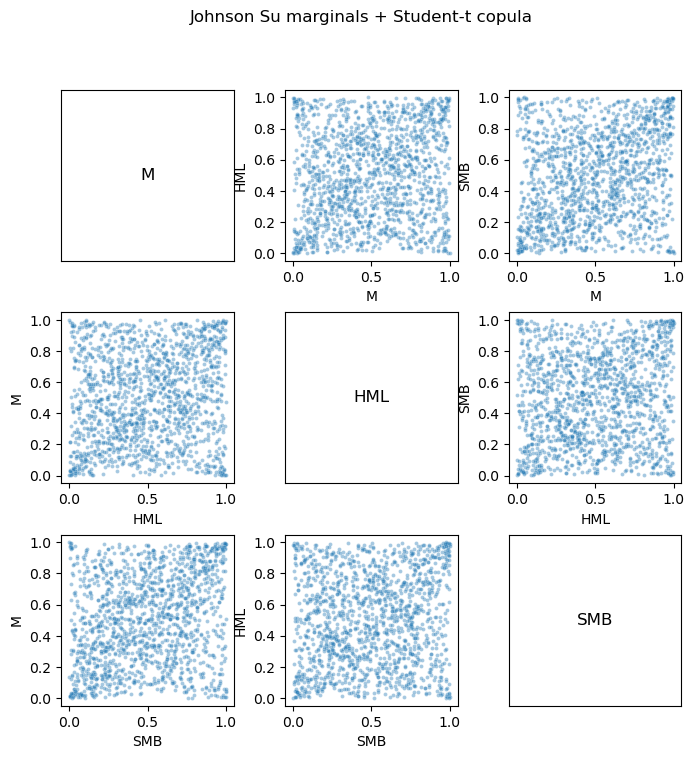

In [3]:
def copula_pair_panel(cop, title, n=1500):

    sampled = pd.DataFrame(cop.random(n), columns=factors)

    fig, axes = plt.subplots(3, 3, figsize=(8, 8))

    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    for i, ri in enumerate(factors):

        for j, cj in enumerate(factors):

            if i == j:

                axes[i, j].text(0.5, 0.5, ri.upper(), fontsize=12, ha='center', va='center')

                axes[i, j].set_xticks([]); axes[i, j].set_yticks([])

            else:

                sns.scatterplot(x=sampled[ri], y=sampled[cj], alpha=0.4, s=8, ax=axes[i, j])

                axes[i, j].set_xlabel(ri.upper()); axes[i, j].set_ylabel(cj.upper())

    plt.suptitle(title, fontsize=12)

    plt.show()



for F in families:

    for C in copula_families:

        copula_pair_panel(fitted_copulas[F][C], f"{F} marginals + {C} copula")

## Preserve the 6 fitted copulas for notebook 6

In [4]:
state["copula_families"] = copula_families

# Pickle the fitted copula objects directly — copulae's classes are picklable.

state["fitted_copulas"] = fitted_copulas



with open("three_asset_state.pkl", "wb") as fh:

    pickle.dump(state, fh)



print(f"updated three_asset_state.pkl ({os.path.getsize('three_asset_state.pkl'):,} bytes)")

print("joint model grid: 3 marginal families × 2 copulas = 6 joint models")

updated three_asset_state.pkl (108,251 bytes)
joint model grid: 3 marginal families × 2 copulas = 6 joint models
